In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
import os
import tqdm
import cv2 as cv
from scipy.spatial import Voronoi, voronoi_plot_2d 
import ast
from shapely import Polygon

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [3]:
aoslo_folder_path = '/home/codebind/thesis-data-preprocessing/data'
aoslo_name = '2538_right_retina_Confocal_RPE_2023-09-10'


In [4]:
cone_csv = pd.read_csv('/home/codebind/thesis-data-preprocessing/data/2538_right_retina_Confocal_RPE_2023-09-10/cone_coords.csv', skipinitialspace=True)
image_ids = cone_csv['image_id'].unique() #different image_id of same Specific patient  

for image_id in image_ids:
    cell_data = cone_csv[(cone_csv['image_id'] == image_id)].reset_index(drop=True)
    #filename = str(cell_data['filename'].to_numpy()[0] + 'f')
    #filename = filename.replace('confocal', 'calculated') # changed
    #sample_image = cv.imread(os.path.join(aoslo_folder_path, aoslo_name, 'AOSLO', filename), cv.IMREAD_GRAYSCALE)
    #sample_image = tifffile.imread("/home/codebind/thesis-data-preprocessing/data/2538_right_retina_Confocal_RPE_2023-09-10/AOSLO/2538_od_24_654_1_0_calculated_1p0_ref_44_lps_8_sr_n_25_cropped_5.tiff")
    #sample_pixels = np.array(sample_image)
    #samp_h = sample_pixels.shape[0]
    #samp_w = sample_pixels.shape[1]
    
    #1. cone center coordinates are populated
    cone_center_coords = []
    for cell in range(0, cell_data.shape[0]):
        cone_center_coords.append([cell_data['cone_x_local_pix'][cell], cell_data['cone_y_local_pix'][cell]])
    print(cone_center_coords)

    break

[[435, 220], [460, 221], [483, 221], [498, 221], [511, 223], [445, 224], [472, 225], [492, 231], [437, 233], [453, 234], [463, 235], [504, 236], [476, 237], [442, 243], [511, 243], [454, 245], [466, 245], [490, 245], [476, 248], [500, 252], [467, 259], [453, 261], [494, 268], [446, 270], [473, 273], [506, 273], [459, 275], [438, 277], [483, 277], [499, 283], [451, 284], [509, 284], [465, 289], [476, 290], [488, 294], [499, 295], [442, 296], [512, 298], [454, 299], [485, 256], [402, 46], [367, 48], [433, 49], [395, 50], [416, 52], [377, 54], [427, 59], [408, 60], [384, 62], [364, 63], [403, 65], [418, 66], [377, 72], [393, 75], [422, 76], [364, 77], [431, 80], [412, 82], [369, 84], [384, 87], [396, 89], [422, 90], [434, 92], [366, 95], [408, 96], [379, 99], [432, 104], [419, 103], [401, 104], [361, 106], [374, 110], [411, 110], [425, 113], [402, 118], [358, 121], [392, 122], [434, 122], [376, 123], [423, 125], [388, 109], [394, 99], [460, 46], [483, 46], [502, 50], [514, 52], [441, 56],

In [5]:
vor = Voronoi(cone_center_coords)

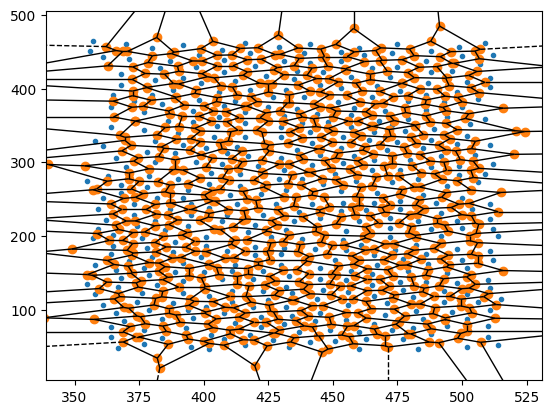

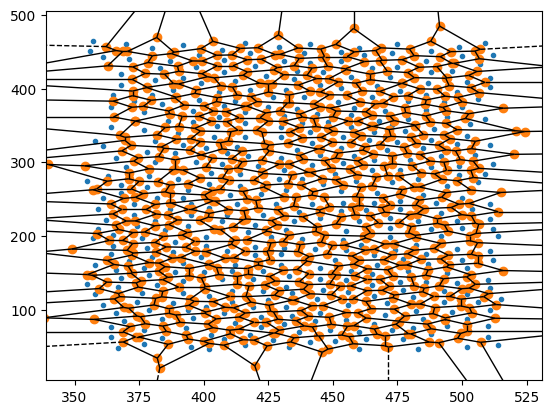

In [6]:
voronoi_plot_2d(vor)

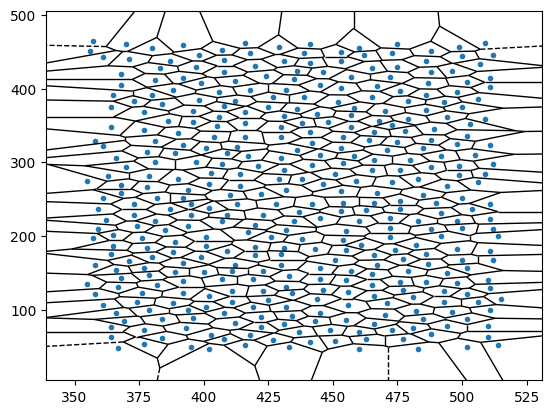

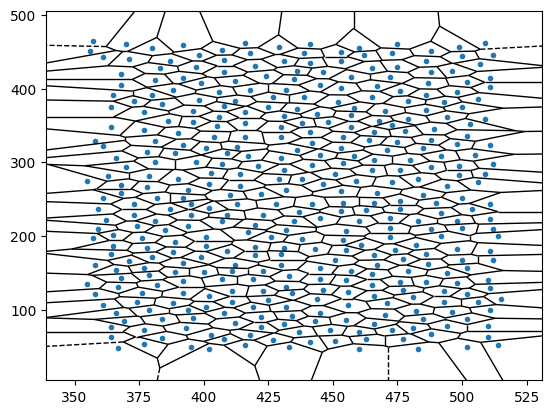

In [7]:
fig, ax = plt.subplots() 
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black')

In [8]:
vor = Voronoi(cone_center_coords)
poly_coords = []
centers = []
circumference_points = []
for region_index in vor.regions:
    if not -1 in region_index and len(region_index) > 0:
        temp = [list(map(int, vor.vertices[i])) for i in region_index]
        # Compute center
        poly = Polygon(temp)
        centroid = poly.centroid
        center = np.array([centroid.x, centroid.y])
    
        # Compute radius as the distance from centroid to the nearest vertex
        distances = np.linalg.norm(temp - center, axis = 1)
        min_distance_index = np.argmin(distances)
        closest_vertex = np.array(temp[min_distance_index])
        
        if np.any(closest_vertex < 0):
          continue
        

        centers.append(center)
        circumference_points.append(closest_vertex)
        #print(closest_vertex)

        poly_coords.append(np.array([temp]))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


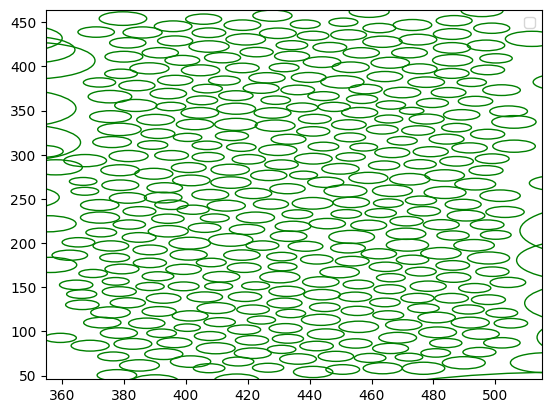

In [11]:
# Plotting the circles
fig, ax = plt.subplots()
# Plot circles
for center, circumference_point in zip(centers, circumference_points):
    radius = np.linalg.norm(center - circumference_point) - 2

    circle = plt.Circle(center, radius, color='g', fill=False)
    ax.add_patch(circle)

ax.set_xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
ax.set_ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)
ax.legend()
plt.show()